In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Downloads\Position_Salaries.csv")
x=dataset.iloc[:,1:-1].values
y=dataset.iloc[:,-1].values

# Feature Scaling

In [42]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
y=y.reshape(len(y),1)
x=sc_x.fit_transform(x)
y=sc_y.fit_transform(y)

In [43]:
print(y)
# y = y.ravel()

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [44]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [45]:
from sklearn.svm import SVR
regressor=SVR(kernel ='rbf')
regressor.fit(x,y)

C:\Users\Rand Rothstein\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SVR()

In [46]:
sc_y.inverse_transform(regressor.predict(sc_x.transform([[6.5]])))

array([170370.0204065])

In [47]:
regressor.predict(sc_x.transform([[6.5]]))

array([-0.27861589])

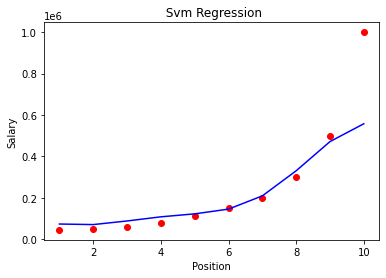

In [48]:
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y),color='red')
plt.plot(sc_x.inverse_transform(x),sc_y.inverse_transform(regressor.predict(x)),color="blue")
plt.title(" Svm Regression")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

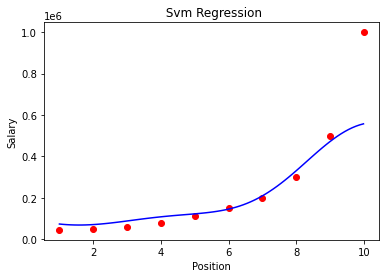

In [55]:
x_grid=np.arange(min(sc_x.inverse_transform(x)),max(sc_x.inverse_transform(x)),0.111)
x_grid=x_grid.reshape(len(x_grid),1)
plt.scatter(sc_x.inverse_transform(x),sc_y.inverse_transform(y),color='red')
plt.plot(x_grid,sc_y.inverse_transform(regressor.predict(sc_x.transform(x_grid))),color="blue")
plt.title(" Svm Regression")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

# Model Selection - R Square

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [75]:
dataset=pd.read_csv(r"C:\Users\Rand Rothstein\Desktop\Machine Learning A-Z (Codes and Datasets)\Model Selection\Regression\Data.csv")
x=dataset.iloc[:, :-1].values
y=dataset.iloc[:, -1].values

In [88]:
y=y.reshape(len(y),1)

In [89]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [90]:
from sklearn.preprocessing import StandardScaler
sc_x=StandardScaler()
sc_y=StandardScaler()
#y_train=y_train.reshape(len(y_train),1)  // wrong method should do rehape before spliting 
x_train=sc_x.fit_transform(x_train)
y_train=sc_y.fit_transform(y_train)

In [91]:
print(x_train)
print(y_train)

[[-1.14 -0.89  0.67  0.52]
 [-0.81 -0.01  0.45  0.15]
 [ 1.77  1.85  0.24 -1.88]
 ...
 [-0.38 -1.25  0.85  0.13]
 [-0.92 -1.04  1.55  0.88]
 [ 1.7   1.06 -1.2  -2.42]]
[[ 1.15]
 [ 0.8 ]
 [-1.31]
 ...
 [ 0.28]
 [ 0.49]
 [-1.54]]


In [92]:
from sklearn.svm import SVR
regressor=SVR(kernel ='rbf')
y_train=y_train.ravel()
regressor.fit(x_train,y_train)

C:\Users\Rand Rothstein\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SVR()

In [93]:
y_pred=sc_y.inverse_transform(regressor.predict(sc_x.transform(x_test)))
np.set_printoptions(precision=2) #number of decimals 
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[434.05 431.23]
 [457.94 460.01]
 [461.03 461.14]
 ...
 [470.6  473.26]
 [439.42 438.  ]
 [460.92 463.28]]


In [94]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.9480784049986258
